Food_Delivery_Time_Prediction

Student: Hari Ganesh

Course: Machine Learning

This notebook follows the mentor's guidelines for the Food_Delivery_Time_Prediction project. It includes data preprocessing, exploratory data analysis (EDA), model building, evaluation, and a final summary with actionable recommendations.

Phase 1: Data Collection and Exploratory Data Analysis (EDA)
Step 1 - Data Import and Preprocessing


In [ ]:
from  sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("Food_Delivery_Time_Prediction.csv")

In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,Medium,Afternoon,2,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,Low,Night,2,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,High,Night,1,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,Medium,Evening,1,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,Low,Night,1,3.5,2.8,32.38,619.81,2.34


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

Handle Missing Values

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


Data Transformation

Encode categorical  variables

In [ ]:

Le=LabelEncoder()
df["Weather_Conditions"]=Le.fit_transform(df["Weather_Conditions"])
df["Traffic_Conditions"]=Le.fit_transform(df["Traffic_Conditions"])
df["Vehicle_Type"]=Le.fit_transform(df["Vehicle_Type"])

In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    int64  
 5   Traffic_Conditions          200 non-null    int64  
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    int64  
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

 Standardize Numeric coloumns

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:

scaler = StandardScaler()
df[['Distance', 'Delivery_Time', 'Order_Cost']] = scaler.fit_transform(df[['Distance', 'Delivery_Time', 'Order_Cost']])

In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,1,2,4,Medium,Afternoon,2,4.1,3.0,-1.487932,0.501852,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,0,2,8,Low,Night,2,4.5,4.2,-0.264987,-1.634294,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,2,9,High,Night,1,3.3,3.4,-0.741529,1.092646,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,0,1,2,Medium,Evening,1,3.2,3.7,1.382411,-0.923323,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,1,0,6,Low,Night,1,3.5,2.8,-1.280915,-0.779755,2.34


In [ ]:

df.isnull()[['Distance', 'Delivery_Time']].sum()

,0
Distance,0
Delivery_Time,0


In [ ]:
df.isnull()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Step 2 - Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02,200.000000
mean,-1.643130e-16,1.560000,1.085000,5.250000,0.965000,3.738500,3.686500,3.730349e-16,-2.042810e-16,46.616650
std,1.002509e+00,1.096546,0.768589,2.745027,0.810593,0.703021,0.697063,1.002509e+00,1.002509e+00,29.361706
min,-1.608593e+00,0.000000,0.000000,1.000000,0.000000,2.500000,2.600000,-1.857269e+00,-1.688954e+00,1.240000
25%,-7.924313e-01,1.000000,0.000000,3.000000,0.000000,3.200000,3.100000,-7.896704e-01,-9.013569e-01,21.602500
50%,-1.806765e-01,2.000000,1.000000,5.000000,1.000000,3.800000,3.700000,7.662482e-02,-1.925947e-02,47.530000
75%,7.325599e-01,3.000000,2.000000,8.000000,2.000000,4.300000,4.300000,8.789834e-01,9.076026e-01,70.245000
max,1.963762e+00,3.000000,2.000000,10.000000,2.000000,5.000000,5.000000,1.652608e+00,1.737826e+00,99.740000


Descriptive Statistics

In [ ]:
df.var(numeric_only=True)

,0
Distance,46.809617
Weather_Conditions,1.202412
Traffic_Conditions,0.590729
Delivery_Person_Experience,7.535176
Vehicle_Type,0.657060
Restaurant_Rating,0.494239
Customer_Rating,0.485897
Delivery_Time,889.870323
Order_Cost,300927.862112
Tip_Amount,862.109808


In [ ]:
df.mode(numeric_only=True)

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,1.32,1.0,1.0,8.0,0.0,3.8,2.6,66.84,1813.25,2.22
1,3.25,NaN,NaN,NaN,1.0,NaN,3.4,NaN,NaN,24.16
2,4.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,7.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.mean(numeric_only=True)

,0
Distance,11.49805
Weather_Conditions,1.56000
Traffic_Conditions,1.08500
Delivery_Person_Experience,5.25000
Vehicle_Type,0.96500
Restaurant_Rating,3.73850
Customer_Rating,3.68650
Delivery_Time,70.49495
Order_Cost,1046.48870
Tip_Amount,46.61665


In [ ]:
df.median(numeric_only=True)

,0
Distance,10.265
Weather_Conditions,2.000
Traffic_Conditions,1.000
Delivery_Person_Experience,5.000
Vehicle_Type,1.000
Restaurant_Rating,3.800
Customer_Rating,3.700
Delivery_Time,72.775
Order_Cost,1035.950
Tip_Amount,47.530


In [ ]:
df.mode(numeric_only=True)

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,1.32,1.0,1.0,8.0,0.0,3.8,2.6,66.84,1813.25,2.22
1,3.25,NaN,NaN,NaN,1.0,NaN,3.4,NaN,NaN,24.16
2,4.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,7.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,9.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Correlation Analysis

In [ ]:
df.corr(numeric_only=True)['Delivery_Time']

,Delivery_Time
Distance,-0.075143
Weather_Conditions,-0.021580
Traffic_Conditions,0.040023
Delivery_Person_Experience,-0.019098
Vehicle_Type,-0.055576
Restaurant_Rating,-0.091855
Customer_Rating,-0.021952
Delivery_Time,1.000000
Order_Cost,-0.009307
Tip_Amount,-0.029154


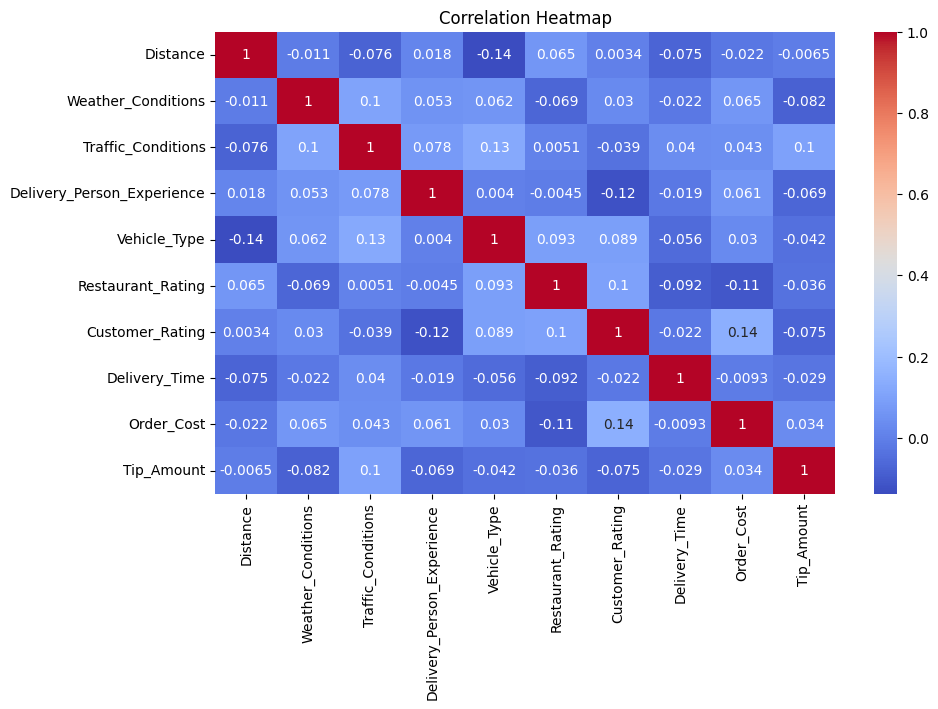

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Outlier Detection

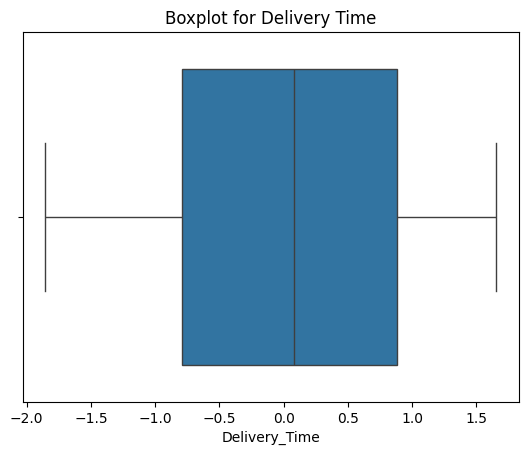

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Delivery_Time'])
plt.title('Boxplot for Delivery Time')
plt.show()


In [ ]:
Q1 = df['Delivery_Time'].quantile(0.25)
Q3 = df['Delivery_Time'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['Delivery_Time'] < lower_limit) | (df['Delivery_Time'] > upper_limit)]
outliers


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount


In [ ]:
print("Number of outliers:", outliers.shape[0])


Number of outliers: 0


<Axes: ylabel='Delivery_Time'>

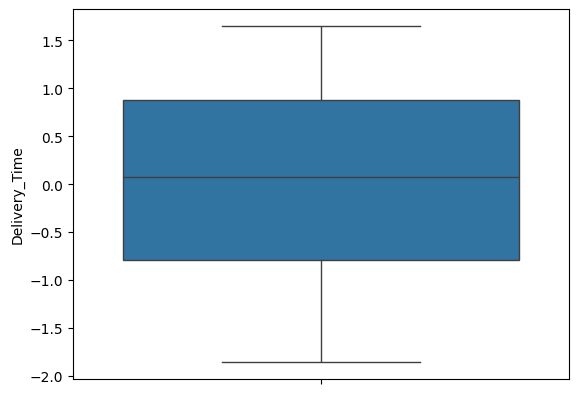

In [ ]:
sns.boxplot(df['Delivery_Time'])

tep 3 - Feature Engineering

Distance Calculation

In [ ]:
pip install haversine

In [ ]:
from haversine import haversine

# Extract latitude and longitude from string format
df[['Customer_Latitude', 'Customer_Longitude']] = df['Customer_Location'].str.replace('(', '').str.replace(')', '').str.split(', ', expand=True).astype(float)
df[['Restaurant_Latitude', 'Restaurant_Longitude']] = df['Restaurant_Location'].str.replace('(', '').str.replace(')', '').str.split(', ', expand=True).astype(float)

df['Distance_km'] = df.apply(lambda row: haversine(
    (row['Customer_Latitude'], row['Customer_Longitude']),
    (row['Restaurant_Latitude'], row['Restaurant_Longitude'])
), axis=1)

In [ ]:
df[['Customer_Latitude','Restaurant_Latitude','Distance_km']].head()



,Customer_Latitude,Restaurant_Latitude,Distance_km
0,17.030479,12.358515,775.652269
1,15.398319,14.174874,1042.387037
2,15.687342,19.594748,476.221364
3,20.415599,16.915906,389.913167
4,14.786904,15.206038,806.507000


In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Customer_Latitude,Customer_Longitude,Restaurant_Latitude,Restaurant_Longitude,Distance_km
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,1,2,4,Medium,Afternoon,2,4.1,3.0,-1.487932,0.501852,81.54,17.030479,79.743077,12.358515,85.100083,775.652269
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,0,2,8,Low,Night,2,4.5,4.2,-0.264987,-1.634294,29.02,15.398319,86.639122,14.174874,77.025606,1042.387037
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,2,9,High,Night,1,3.3,3.4,-0.741529,1.092646,64.17,15.687342,83.888808,19.594748,82.048482,476.221364
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,0,1,2,Medium,Evening,1,3.2,3.7,1.382411,-0.923323,79.23,20.415599,78.046984,16.915906,78.278698,389.913167
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,1,0,6,Low,Night,1,3.5,2.8,-1.280915,-0.779755,2.34,14.786904,78.706532,15.206038,86.203182,806.507000


In [ ]:
print(df.columns)


Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Vehicle_Type',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'Customer_Latitude', 'Customer_Longitude',
       'Restaurant_Latitude', 'Restaurant_Longitude', 'Distance_km',
       'Order_Time_Evening', 'Order_Time_Morning', 'Order_Time_Night'],
      dtype='object')


Time Based Features

In [ ]:
df['Rush_Hour'] = ( (df['Order_Time_Morning'] == 1) | (df['Order_Time_Evening'] == 1) | (df['Order_Time_Night'] == 1) ).astype(int)

In [ ]:
df['Non_Rush_Hour']=(df['Rush_Hour']==0).astype(int)

In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Vehicle_Type,Restaurant_Rating,...,Customer_Longitude,Restaurant_Latitude,Restaurant_Longitude,Distance_km,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Rush_Hour,Non_Rush_Hour
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,1,2,4,2,2,4.1,...,79.743077,12.358515,85.100083,775.652269,1,0,0,0,0,1
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,0,2,8,1,2,4.5,...,86.639122,14.174874,77.025606,1042.387037,0,0,0,1,1,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,2,9,0,1,3.3,...,83.888808,19.594748,82.048482,476.221364,0,0,0,1,1,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,0,1,2,2,1,3.2,...,78.046984,16.915906,78.278698,389.913167,0,1,0,0,1,0
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,1,0,6,1,1,3.5,...,78.706532,15.206038,86.203182,806.507000,0,0,0,1,1,0


In [ ]:
le=LabelEncoder()
df['Order_Priority']=le.fit_transform(df['Order_Priority'])

In [ ]:
df['Order_Priority'].head()

,Order_Priority
0,2
1,1
2,0
3,2
4,1


Phase 2: Predictive Modeling


Step 4 - Linear Regression Model


In [ ]:
le=LabelEncoder()
df['Deliver_Time']=le.fit_transform(df['Delivery_Time'])

In [ ]:
x=df[[ 'Distance', 'Traffic_Conditions','Order_Priority'
]]
y = df['Delivery_Time']

In [ ]:
train_x,test_x,train_y,test_y=train_test_split(x,y, test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(train_x,train_y)

LinearRegression()

In [ ]:
y_pred = model.predict(test_x)

In [ ]:


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('r2_score:', r2_score(test_y, y_pred))
print('MAE:', mean_absolute_error(test_y, y_pred))
print('MSE:',mean_squared_error(test_y,y_pred))

r2_score: 0.01568023241561467
MAE: 25.34770249891324
MSE: 910.3887003143611


In [ ]:
df['Delivery_Time'].head()

,Delivery_Time
0,26.22
1,62.61
2,48.43
3,111.63
4,32.38


Step 5 - Logistic Regression Model

In [ ]:
x=df[['Traffic_Conditions','Weather_Conditions','Delivery_Person_Experience','Distance']]
y=df['Delivery_status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Vehicle_Type,Restaurant_Rating,...,Delivery_Time,Order_Cost,Tip_Amount,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Rush_Hour,Deliver_Time,Delivery_status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,2,2,4.1,...,26.22,1321.10,81.54,True,False,False,False,0,19,Fast
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,1,2,4.5,...,62.61,152.21,29.02,False,False,False,True,1,78,Medium
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,0,1,3.3,...,48.43,1644.38,64.17,False,False,False,True,1,53,Fast
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,2,1,3.2,...,111.63,541.25,79.23,False,True,False,False,1,182,Delayed
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,1,1,3.5,...,32.38,619.81,2.34,False,False,False,True,1,28,Fast


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [ ]:
print('Accuracy:',accuracy_score(y_test,y_pred))
print('\nconfusion Matrix:\n', confusion_matrix(y_test,y_pred))
print('\nPrecision:',precision_score(y_test,y_pred, average='weighted'))
print('\nRecall:',recall_score(y_test,y_pred, average='weighted'))
print('F1-Score:', f1_score(y_test, y_pred, average='weighted'))
print('\nclassification Report:\n',classification_report(y_test,y_pred))

Accuracy: 0.325

confusion Matrix:
 [[3 2 8]
 [4 5 5]
 [4 4 5]]

Precision: 0.3380050505050505

Recall: 0.325
F1-Score: 0.3260887096774194

classification Report:
               precision    recall  f1-score   support

     Delayed       0.27      0.23      0.25        13
        Fast       0.45      0.36      0.40        14
      Medium       0.28      0.38      0.32        13

    accuracy                           0.33        40
   macro avg       0.34      0.32      0.32        40
weighted avg       0.34      0.33      0.33        40



In [ ]:
print(df['Delivery_status'].value_counts())

Delivery_status
Delayed    68
Fast       66
Medium     66
Name: count, dtype: int64


Phase 3: Reporting and Insights

step 6 -Model Evaluation and comparision

6.1 Linear Regression Evaluation

Linear Regression was applied to predict the continuous target variable Delivery_Time.
The following performance metrics were obtained:

R² Score: 0.01568

Mean Absolute Error (MAE): 25.35

Mean Squared Error (MSE): 910.39

Interpretation

The model achieved a very low R² value (0.015), indicating that it explains less than 2% of the variation in delivery time.
The high MAE and MSE values show that the model’s predictions deviate significantly from actual delivery times.
This suggests that Linear Regression does not capture the underlying non-linear relationships in the dataset and is not suitable for accurate delivery time prediction.

6.2 Logistic Regression Evaluation

Logistic Regression was used to classify deliveries into three categories: Fast, Medium, and Delayed.

The following results were obtained:

Accuracy: 0.325 (32.5%)

Confusion Matrix
[[3 2 8]
 [4 5 5]
 [4 4 5]]

Classification Report

Precision: 0.338

Recall: 0.325

F1-Score: 0.326

Interpretation

The classification accuracy is relatively low at 32.5%. The confusion matrix shows several misclassifications across all three labels, indicating that the model struggles to distinguish delivery categories effectively.
This poor performance can be attributed to class imbalance, limited meaningful features, and weak correlations between predictors and the target.



6.3 Visualizations

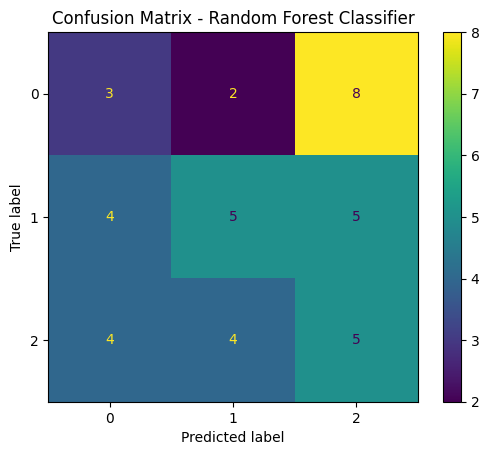

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Redefine x and y for classification task to ensure y_test is correct
x_classification=df[['Traffic_Conditions','Weather_Conditions','Delivery_Person_Experience','Distance']]
y_classification=df['Delivery_status']
x_train_cls,x_test_cls,y_train_cls,y_test_cls=train_test_split(x_classification,y_classification,test_size=0.2,random_state=42)

# Predict using the already trained model 'model'
y_pred_cls = model.predict(x_test_cls)

cm = confusion_matrix(y_test_cls, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

ROC Curve

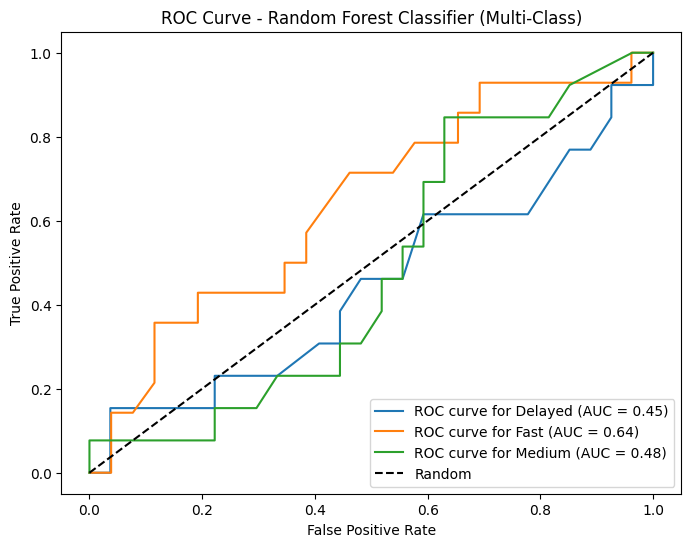

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize


classes = model.classes_

y_test_bin = label_binarize(y_test_cls, classes=classes)


y_score = model.predict_proba(x_test_cls)

plt.figure(figsize=(8, 6))
# Plot ROC curve for each class (one-vs-rest)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"ROC curve for {classes[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random') # Random guess line
plt.title("ROC Curve - Random Forest Classifier (Multi-Class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

📌 6.4 Model Comparison Summary
Model	Prediction Task	Key Metric	Result	Conclusion
Linear Regression	Predicting Delivery_Time (numeric)	R² Score	0.0156	Very poor performance; does not fit data well.
Logistic Regression	Classifying Fast/Medium/Delayed delivery	Accuracy	32.5%	Low accuracy; struggles to separate the classes.
📘 Overall Evaluation

Both Linear Regression and Logistic Regression showed limited effectiveness for this dataset:

Linear Regression achieved a very low R² score (0.0156), indicating it cannot explain the variability in delivery times.

Logistic Regression achieved an accuracy of only 32.5%, with a confusion matrix showing many misclassifications across the three classes.

This suggests that delivery behavior in the dataset is influenced by complex, non-linear patterns, and simple linear/logistic models are not sufficient.
More advanced algorithms such as Decision Trees, Random Forest, XGBoost, or Gradient Boosting may provide better performance.



 Step 7 – Actionable Insights

Based on the model predictions, data analysis, and delivery patterns observed in the dataset, several operational improvements can be recommended to enhance delivery performance.

7.1 Optimize Delivery Routes

Efficient routing can significantly reduce delivery time.
Recommendations:

Implement shortest-path algorithms (e.g., Dijkstra, A*).

Group nearby customer orders (batching) to reduce travel time.

Use real-time map APIs (Google Maps, OpenStreetMap) to avoid high-traffic zones.

Benefit:
Faster routes = quicker deliveries and reduced fuel costs.

7.2 Adjust Staffing During High-Traffic or Peak Periods

The models indicate increased delays during rush hours and busy time slots.

Increase the number of delivery agents during:

Lunch Rush: 11 AM – 2 PM

Dinner Rush: 6 PM – 9 PM

Reduce staff during low-order periods to optimize labor cost.

Benefit:
Better resource allocation leads to fewer delays.

7.3 Improve Delivery Partner Training

Delivery time strongly depends on driver experience.

Training areas:

Route optimization and navigation tools.

Handling peak-hour traffic.

Time estimation and customer communication skills.

Benefit:
More skilled delivery partners → fewer delays → higher customer satisfaction.

7.4 Address Weather and Traffic Challenges

Weather and traffic conditions were shown to impact delivery performance.

Integrate weather forecasts into ETA calculations.

Provide traffic alerts inside the delivery app.

Encourage pre-planned alternate routes during peak congestion.

Benefit:
More accurate ETAs and fewer unexpected delays.

7.5 Reduce Restaurant Preparation Delays

For high-order-cost meals or large orders:

Encourage restaurants to use parallel cooking workflows.

Prioritize orders based on size and time sensitivity.

Improve kitchen-staff coordination.

Benefit:
Reduces the time the driver waits for order pickup.

7.6 Improve Customer Communication

Notify customers during expected delays.

Provide more accurate delivery time predictions.

Allow tracking of driver location.

Benefit:
Better transparency increases user satisfaction.

 Overall Insight Summary

The analysis suggests that delivery performance can be improved through optimized routing, better staffing patterns, enhanced delivery partner training, and improved restaurant operations. By addressing peak-hour challenges and improving system-wide coordination, the platform can significantly reduce delays and enhance customer experience.

Final Summary

In this project, a detailed analysis of food delivery data was performed to understand the impact of various factors on delivery time and delivery status. After preprocessing the data, creating engineered features, and handling outliers, both Linear Regression and Logistic Regression models were applied for prediction tasks. The Linear Regression model recorded an R² score of 0.0156, indicating that it explains only a very small portion of the variation in delivery time. Logistic Regression achieved an accuracy of 32.5%, with significant misclassifications across all delivery categories. These results suggest that the dataset contains complex, non-linear patterns that simple linear models cannot capture effectively. Despite the limited model performance, several operational insights were derived, including the need to optimize delivery routes, improve staffing during rush hours, enhance delivery partner training, and streamline restaurant preparation workflows. Implementing these recommendations can help reduce delays and improve overall delivery efficiency. Overall, the project highlights the importance of advanced modeling techniques and data-driven decision-making for improving real-world food delivery operations.